In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm    
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve

In [2]:
data_dir = '/home/rmhihbp/my_ukb_thesis/data'
target_col = 'def_CVD_AF_HF_AFTER'

continuous_cols = ['age_defined_baseline', 'BMI', 'sleep_hours', ]  
binary_cols = ['genetic_sex', 'mental_doctor', 'education_degree',
            'father_cvd_history', 'mother_cvd_history', 'sibling_cvd_history',
            'smoking_1', 'smoking_2', 'alcohol_2', 'activity_walking_incl_is_active']
final_features = continuous_cols + binary_cols

df_B = pd.read_parquet(os.path.join(data_dir, 'split_B_train.parquet')) 
df_C = pd.read_parquet(os.path.join(data_dir, 'split_C_test.parquet'))

X_B_raw, Y_B = df_B[final_features], df_B[target_col]
X_C_raw, Y_C = df_C[final_features], df_C[target_col]

In [3]:
# MICE imputation
imputer = IterativeImputer(max_iter=10, random_state=42)
X_B_imp = pd.DataFrame(imputer.fit_transform(X_B_raw), columns=final_features, index=X_B_raw.index)
X_C_imp = pd.DataFrame(imputer.transform(X_C_raw), columns=final_features, index=X_C_raw.index)

for col in binary_cols: # round and clip binary features to ensure they remain 0 or 1 after imputation
    X_B_imp[col] = np.clip(np.round(X_B_imp[col]), 0, 1)
    X_C_imp[col] = np.clip(np.round(X_C_imp[col]), 0, 1)

In [4]:
# Standardize continuous features
scaler = StandardScaler()
X_B_final = X_B_imp.copy()
X_C_final = X_C_imp.copy()
X_B_final[continuous_cols] = scaler.fit_transform(X_B_imp[continuous_cols])
X_C_final[continuous_cols] = scaler.transform(X_C_imp[continuous_cols])

In [21]:
# Logistic Regression
X_B_sm = sm.add_constant(X_B_final) # add intercept term for statsmodels
X_C_sm = sm.add_constant(X_C_final)

logit_model = sm.Logit(Y_B, X_B_sm).fit(disp=False) # fit logistic regression model on training data
print(logit_model.summary())

print('\n=== (Odds Ratios) ===')
conf = logit_model.conf_int()
conf['OR'] = logit_model.params
conf.columns = ['2.5% CI', '97.5% CI', 'Odds Ratio'] # calculate confidence intervals and odds ratios

result_table = np.exp(conf)
result_table['P-value'] = logit_model.pvalues # add p-values to the result table
print(result_table.sort_values(by='P-value', ascending=True))

                            Logit Regression Results                           
Dep. Variable:     def_CVD_AF_HF_AFTER   No. Observations:               321188
Model:                           Logit   Df Residuals:                   321174
Method:                            MLE   Df Model:                           13
Date:                 Sun, 08 Mar 2026   Pseudo R-squ.:                 0.09057
Time:                         16:42:08   Log-Likelihood:                -86944.
converged:                        True   LL-Null:                       -95604.
Covariance Type:             nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -2.9052      0.028   -102.056      0.000      -2.961      -2.849
age_defined_baseline                0.6972      0.008     87

In [9]:
y_train_prob = logit_model.predict(X_B_sm) # predict probabilities on training data
y_test_prob = logit_model.predict(X_C_sm) # predict probabilities on test data

def calculate_auc_ci(y_true, y_pred_prob, n_bootstraps=1000, alpha=0.95): # bootstrap method to calculate confidence intervals for AUC
    bootstrapped_scores = []
    rng = np.random.RandomState(42)
    indices = np.arange(len(y_true))
    for i in range(n_bootstraps):
        boot_indices = rng.choice(indices, size=len(indices), replace=True)
        if len(np.unique(y_true.iloc[boot_indices])) < 2:
            continue
        score = roc_auc_score(y_true.iloc[boot_indices], y_pred_prob.iloc[boot_indices])
        bootstrapped_scores.append(score)
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    lower = sorted_scores[int((1.0 - alpha) / 2.0 * len(sorted_scores))]
    upper = sorted_scores[int((1.0 + alpha) / 2.0 * len(sorted_scores))]
    return roc_auc_score(y_true, y_pred_prob), lower, upper

train_auc_logit, train_ci_lower, train_ci_upper = calculate_auc_ci(Y_B, y_train_prob)
test_auc_logit, test_ci_lower, test_ci_upper = calculate_auc_ci(Y_C, y_test_prob)
print(f'Logistic Regression AUC (Train, Split B): {train_auc_logit:.4f} (95% CI: {train_ci_lower:.4f} - {train_ci_upper:.4f})')
print(f'Logistic Regression AUC (Test, Split C): {test_auc_logit:.4f} (95% CI: {test_ci_lower:.4f} - {test_ci_upper:.4f})')

Logistic Regression AUC (Train, Split B): 0.7276 (95% CI: 0.7246 - 0.7305)
Logistic Regression AUC (Test, Split C): 0.7262 (95% CI: 0.7204 - 0.7314)


In [10]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_B_final, Y_B) # fit random forest model on training data
y_pred_prob_rf = rf_model.predict_proba(X_C_final)[:, 1] # predict probabilities on test data

auc_rf = roc_auc_score(Y_C, y_pred_prob_rf)
print(f'Random Forest AUC (Test, Split C): {auc_rf:.4f}')

Random Forest AUC (Test, Split C): 0.7232


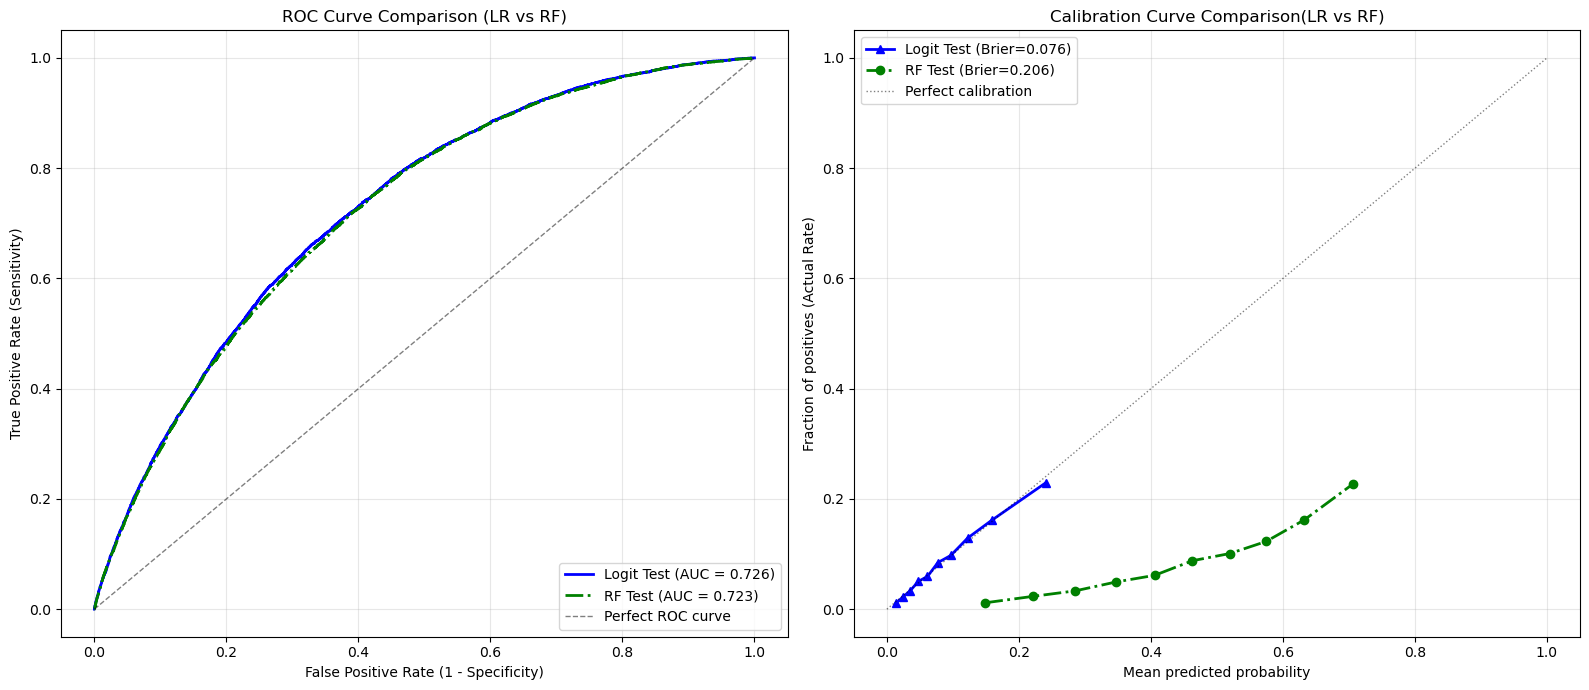

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Roc curve: Logistic Regression vs Random Forest
fpr_test, tpr_test, _ = roc_curve(Y_C, y_test_prob)
fpr_rf_test, tpr_rf_test, _ = roc_curve(Y_C, y_pred_prob_rf)

ax1.plot(fpr_test, tpr_test, label=f'Logit Test (AUC = {test_auc_logit:.3f})', color='blue', lw=2)
ax1.plot(fpr_rf_test, tpr_rf_test, label=f'RF Test (AUC = {auc_rf:.3f})', color='green', lw=2, linestyle='-.')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect ROC curve', alpha=0.5)
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve Comparison (LR vs RF)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)


# Calibration curve: Logistic Regression vs Random Forest
frac_pos_test, mean_pred_test = calibration_curve(Y_C, y_test_prob, n_bins=10, strategy='quantile')
frac_pos_rf, mean_pred_rf = calibration_curve(Y_C, y_pred_prob_rf, n_bins=10, strategy='quantile')

ax2.plot(mean_pred_test, frac_pos_test, '^-', label=f'Logit Test (Brier={brier_score_loss(Y_C, y_test_prob):.3f})', color='blue', lw=2)
ax2.plot(mean_pred_rf, frac_pos_rf, 'o-.', label=f'RF Test (Brier={brier_score_loss(Y_C, y_pred_prob_rf):.3f})', color='green', lw=2)

ax2.plot([0, 1], [0, 1], 'k:', lw=1, label='Perfect calibration', alpha=0.5)
ax2.set_xlabel('Mean predicted probability')
ax2.set_ylabel('Fraction of positives (Actual Rate)')
ax2.set_title('Calibration Curve Comparison(LR vs RF)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

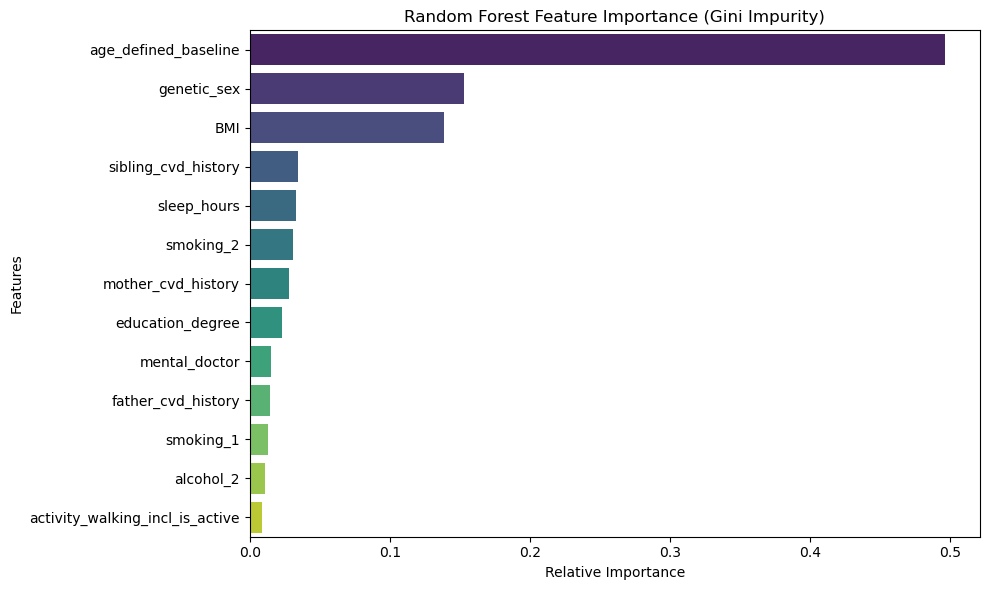

In [16]:
# supplementary table: feature importance from random forest
rf_importances = rf_model.feature_importances_

rf_imp_df = pd.DataFrame({ 
    'Feature': final_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False) # create a DataFrame for feature importance and sort by importance

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=rf_imp_df, palette='viridis', legend=False)
plt.title('Random Forest Feature Importance (Gini Impurity)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()